# **Week 8: Central Limit Theorem and Sampling Distributions**

```
.------------------------------------.
|   __  ____  ______  _  ___ _____   |
|  |  \/  \ \/ / __ )/ |/ _ \___  |  |
|  | |\/| |\  /|  _ \| | | | | / /   |
|  | |  | |/  \| |_) | | |_| |/ /    |
|  |_|  |_/_/\_\____/|_|\___//_/     |
'------------------------------------'

```

## **Pre-Configurating the Notebook**

### **Switching to the R Kernel on Colab**

By default, Google Colab uses Python as its programming language. To use R instead, you’ll need to manually switch the kernel by going to **Runtime > Change runtime type**, and selecting R as the kernel. This allows you to run R code in the Colab environment.

However, our notebook is already configured to use R by default. Unless something goes wrong, you shouldn’t need to manually change runtime type.

### **Importing Required Packages**
**Run the following lines of code**:

In [1]:
#Do not modify

setwd("/content")

# Remove `MXB107-Notebooks` if exists,
if (dir.exists("MXB107-Notebooks")) {
  system("rm -rf MXB107-Notebooks")
}

# Fork the repository
system("git clone https://github.com/ArwenNugteren/MXB107-Notebooks")

# Change working directory to "MXB107-Notebooks"
setwd("MXB107-Notebooks")

#
invisible(source("R/preConfigurated.R"))

Loading required package: ggplot2

Loading required package: dplyr


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: tidyr

Loading required package: stringr

Loading required package: magrittr


Attaching package: ‘magrittr’


The following object is masked from ‘package:tidyr’:

    extract


Loading required package: IRdisplay

Loading required package: png

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘png’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: grid

Loading required package: knitr

Loading required package: jpeg

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘jpeg’”
I

**Do not modify the following**

In [2]:
if (!require("testthat")) install.packages("testthat"); library("testthat")

test_that("Test if all packages have been loaded", {

  expect_true(all(c("ggplot2", "tidyr", "dplyr", "stringr", "magrittr", "knitr") %in% loadedNamespaces()))

})

Loading required package: testthat


Attaching package: ‘testthat’


The following objects are masked from ‘package:magrittr’:

    equals, is_less_than, not




Test passed with 1 success 🎊.


# Warm-up activity: Illustrating the CLT
Consider playing Dungeons and Dragons as a wizard, dealing damage based on a combination of D6 rolls where you want to roll high values to deal a lot of damage.

Firstly, by simulating 10,000 dice rolls, plot a histogram of the distribution of values. What distribution does this resemble? Estimate the probability of rolling a 1.

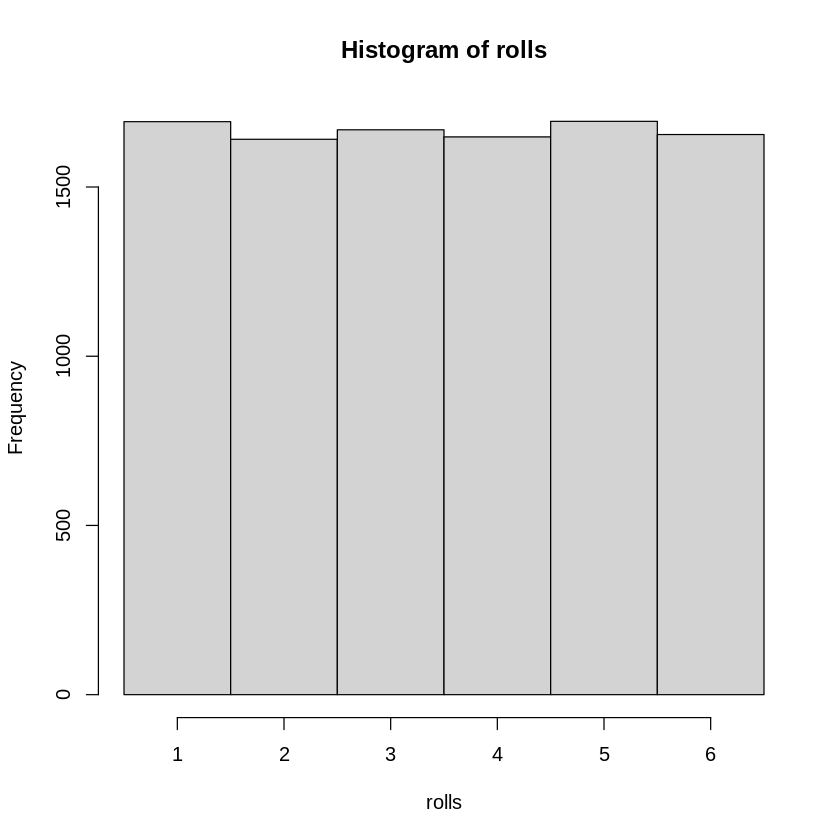

In [6]:
dice = 1:6
n = 10000
rolls = sample(dice, n, replace = T)
hist(rolls, breaks = seq(0.5,6.5, by=1))

<details>
<summary>▶️ Click to show the solution</summary>

```r
dice <- 1:6

N = 10^5
rolls <- sample(dice, N, replace=T)
hist(rolls, breaks=seq(0.5, 6.5, by=1))
# this is a discrete uniform distribution, every roll has equal probability

# probability of a 1
sum(rolls == 1)/N
```

</details>

As a wizard, you have access to the 'Burning Hands' spell, which deals damage based on 3 D6 rolls. Plot this distribution and describe the shape. Estimate the probability of rolling 18 (the highest possible value).

[1] 0.0037

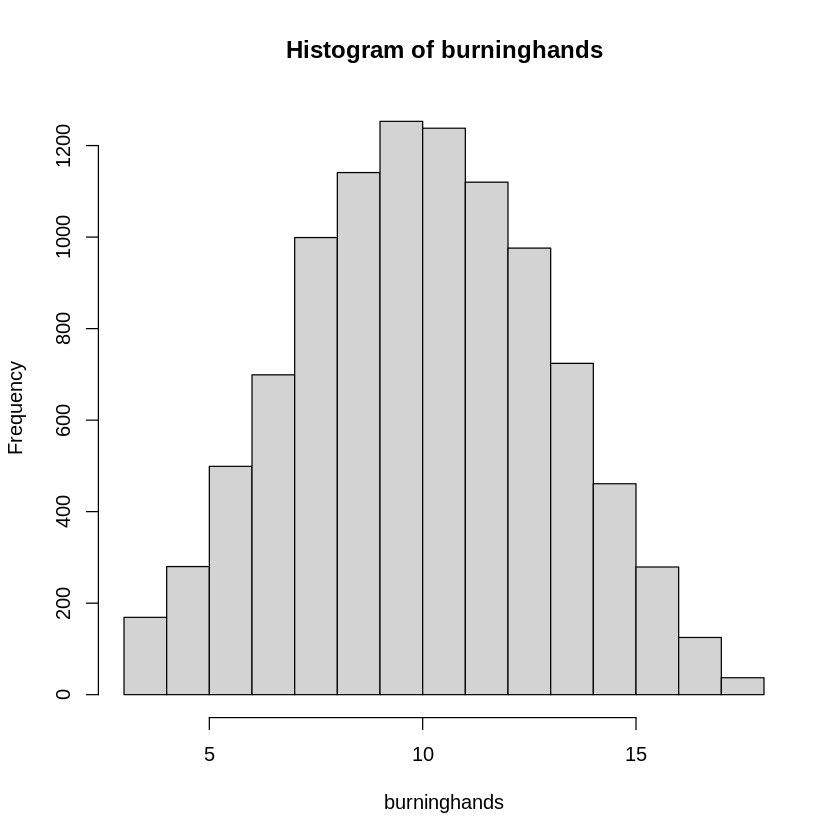

In [9]:
burninghands = replicate(n, sum(sample(dice,3,replace = T)))
hist(burninghands)

sum(burninghands == 18)/n

<details>
<summary>▶️ Click to show the solution</summary>

```r
burning_hands <- replicate(N, sum(sample(dice, 3, replace=TRUE)))
hist(burning_hands)
# the distribution is symmetric and unimodal
# the mean, median and mode all occur around 10

# probability of an 18
sum(burning_hands == 18)/N
```

</details>

As you level up, you gain access to the 'Fireball' spell, which deals 8 D6 of damage. Let's say you consider a "terrible" roll to be a result in the bottom 25% of the range possible values. Estimate the probability of rolling a value this low given 8 D6's. How does it compare to the normal approximation?

[1] 0.0125

[1] 0.01388224

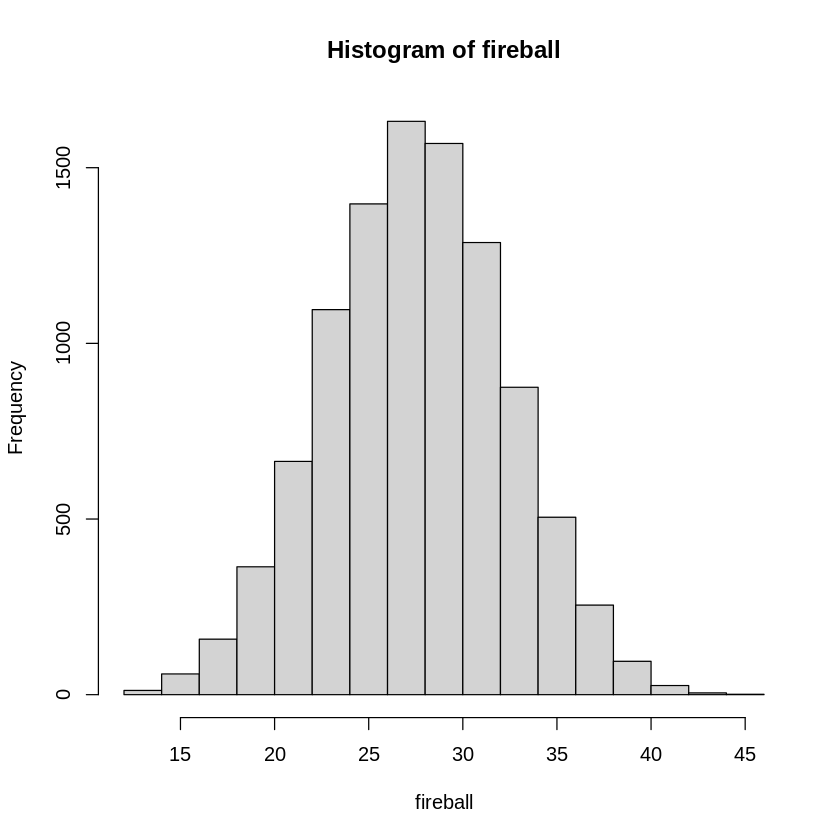

In [16]:
fireball = replicate(n,sum(sample(dice,8,replace=T)))
hist(fireball)

sum(fireball < 18)/n
pnorm(17.5, mean(fireball),sd(fireball))

<details>
<summary>▶️ Click to show the solution</summary>

```r
fireball <- replicate(N, sum(sample(dice, 8, replace=TRUE)))
hist(fireball)

# the result of 8 D6's can range from 8 up to 48, a range of 40
# a value in the bottom 25% would be from 8 up to 17
sum(fireball < 18)/N

pnorm(17.5, mean(fireball), sd(fireball))   # using 17.5 due to continuity correction
# we can see that there is some error in the normal approximation, particularly for uncommon values
```

</details>

At level 9, you can unlock the 'Meteor Swarm' spell, which deals a huge 40 D6 of damage. Plot this distribution. Now what is the probability of a "terrible" roll?

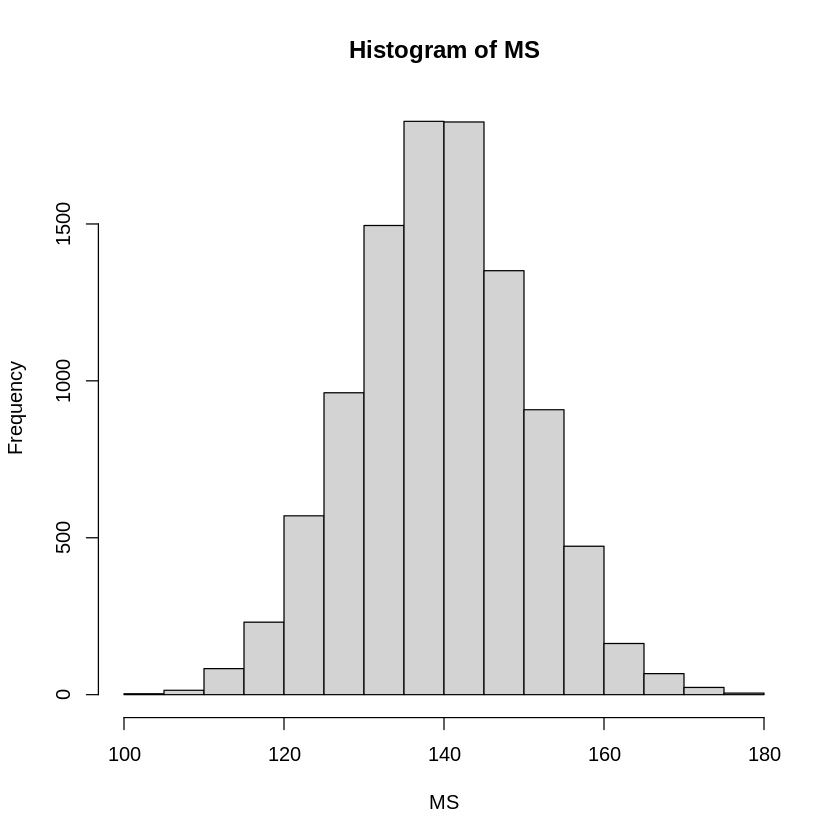

In [14]:
MS = replicate(n,sum(sample(dice,40,replace = T)))
hist(MS)

<details>
<summary>▶️ Click to show the solution</summary>

```r
meteor_swarm <- replicate(N, sum(sample(dice, 40, replace=TRUE)))
hist(meteor_swarm)

# the result of 40 D6's can range from 40 up to 240, a range of 200
# a value in the bottom 25% would be from 50 up to 89
sum(meteor_swarm < 90)/N    

# you may find that the value is 0! You can try with more simulations, or just accept that the true value is a really small probability
```

</details>

We can see from the shape of the histograms that the results become more and more like a bell curve, and the probability of extreme rolls (high or low) becomes rarer. Now estimate the probability of a "terrible" roll for 'Meteor Swarm' using the normal distribution approximation.

In [19]:
sum(MS < 90) / n
pnorm(89.5,mean(MS),sd(MS))

[1] 0

[1] 1.118187e-06

<details>
<summary>▶️ Click to show the solution</summary>

```r
mean_meteor <- mean(meteor_swarm)
sd_meteor <- sd(meteor_swarm)

pnorm(89.5, mean_meteor, sd_meteor)  # using 89.5 for continuity correction

# if you did calculate by simulation before, you should find that the results are pretty similar ...
# or at least that this is a really really small probability!
```

</details>

# Approximating Binomial probabilities

## Question 1
A faculty within a certain University has a quota for an entering class of 800 students for a particular course. Since not all students who are offered a place accept, more than 800 places are offered. Past experience shows that about 70% of students offered a place in this course will accept. The faculty decides to offer places to 1100 students. Assuming the students make their decisions independently and the percentage acceptance is taken as 70%:


a) Give an expression for the probability that the number of students accepting exceeds the class requirements.

b) Use an appropriate distribution to calculate the best approximation for the answer to (a).

In [20]:
1-pnorm(800.5,mean = 770,sd=sqrt(231))

[1] 0.022388

<details>
<summary>▶️ Click to show the solution</summary>

a) Let $X$ be the number of students in 1100 who accept a place, then $X \sim \mathrm{Bin}(1100,0.7)$.
				$$Pr(X > 800) = \sum_{x=801}^{1100} \binom{1100}{x} 0.7^x 0.3^{1100 - x}.$$


b)	$\mu = np = 770$ and $\sigma^2 = np(1-p) = 231$. Since $\mu>10$ and $\sigma^2>10$, we can approximate $X$ with a normal distribution. Let $X \approx Y \sim N(770,231)$.
				$$Pr(X > 800) \approx Pr(Y > 800.5) \quad \text{Using continuity correction.}$$
Using R:
```r
pnorm(800.5,770,sqrt(231), lower.tail = FALSE)
# 0.022388
```
So the probability is approximately 0.0224.

Using R, we can compare this estimate to the exact probability:
```r
pbinom(800,1100,0.7, lower.tail = FALSE)
# 0.02164608
```

</details>

## Question 2
Consider a new university policy that 53\% of students are in support of.
Approximate the probability that more than 50\% of a random sample of size $n$ students are in favour of this new policy when:

a) $n = 9$

b) $n = 99$

c) $n = 999$

In [28]:
ppois(5.5,4.77)
1-pnorm(50.5,52.47,sd=sqrt(23.27))
1- pnorm(500.5,529.47,sqrt(248.85))

[1] 0.6562454

[1] 0.6585039

[1] 0.9668546

<details>
<summary>▶️ Click to show the solution</summary>

Let $X_n$ be the number of students in a sample of $n$ students who agree with the new policy.

Then, the number of students from the sample that we would expect to agree will be $0.53n$, and the variance will be $0.53\times 0.47\times n$.

We are looking for the probabilities $Pr(X_n\geq 0.5n)$.

Note that $0.53\times 9 = 4.77<10$ and so we will have to use the Poisson approximation. However, $0.53\times 99 =52.47>10$ and $0.47\times 99 =46.53>10$ and so we will be able to use the normal approximation for the last two cases.

All of the probabilities are obtained using R.



a) $n = 9$

Let $X_9 \approx Y_9$, where $Y_{9}\sim Poisson(4.77)$. Then,
				$$
				Pr(Y_{9}> 0.50\times 9) =Pr(Y_9\geq5)\approx 0.5183.
				$$
Note that in this example, we could use the exact binomial expression without too much trouble, and get `1 - pbinom(4, 9, 0.53) = 0.5734749`. The approximation is clearly not very accurate in this case.

b) $n = 99$, so that $X_{99}\approx Y_{99}\sim N(52.47,4.966^2)$.
				\begin{align*}
					Pr(X_{99} > 0.5 \times 99) &= Pr(X_{99} > 49.5),\\
						&= Pr(X_{99} \ge 50),\\
						&\approx Pr(Y_{99} > 49.5),\quad \text{Continuity correction},\\
						&\approx 0.7251.
				\end{align*}


c) $n = 999$, so that $X_{999}\approx Y_{999}\sim N(529.47,15.775^2)$.
				\begin{align*}
					Pr(X_{999} > 0.5 \times 999) &= Pr(X_{999} > 499.5),\\
						&= Pr(X_{999} \ge 500),\\
						&\approx Pr(Y_{999} > 499.5),\quad \text{Continuity correction},\\
						&\approx 0.9713.
				\end{align*}

</details>

# CLT for the sample mean









In practice, when the sample size $n$ is sufficiently large, the **CLT approximation** can be applied.
$$
\displaystyle \bar{x} \approx \mathcal{N}\Big(\mu, \frac{\sigma^2}{n}\Big).
$$  

How large $n$ needs to be depends on various factors, such as the **skewness** of the population distribution. A common rule of thumb is that if

$$
n > 30,
$$

the normal approximation is reasonable. However, it is less precise when data are heavily skewed.

## How large should `n` be for skewed distributions?

First, we will visually demonstrate the CLT for populations with different skewness levels. For each example, we will draw 10,000 samples, and compute the sample mean for each, forming the estimated sampling distribution of the sample mean.

### Squared standard Gaussian

Simulate 10,000 samples from $N(0,1)^2$. Plot the results in a histogram. Describe the skewness of this distribution.



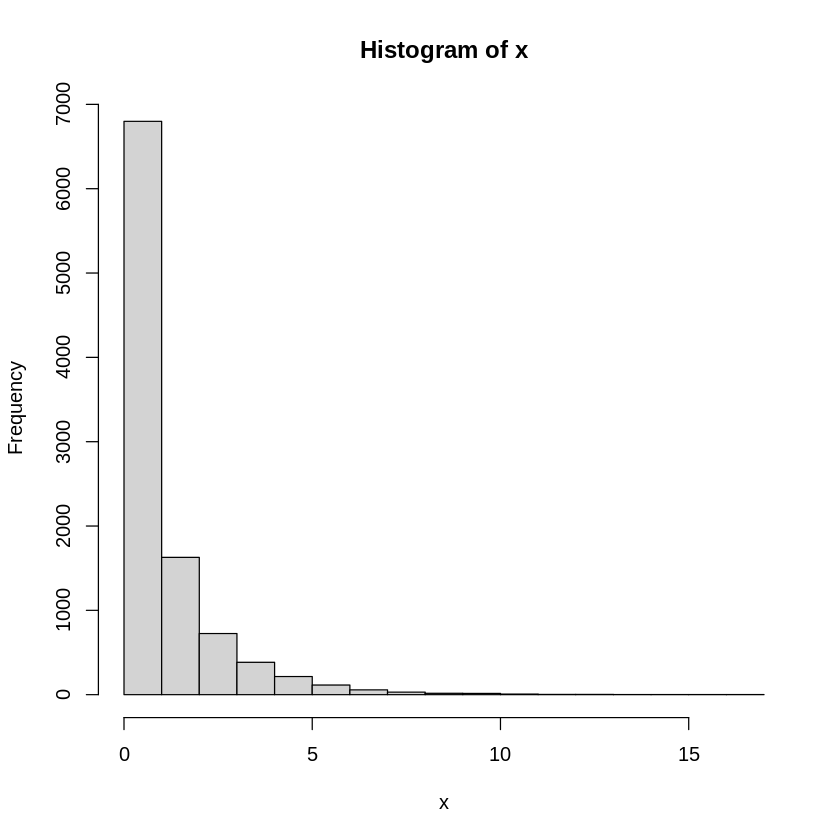

In [29]:
x = rnorm(10^4)^2
hist(x)

<details>
<summary>▶️ Click to show the solution</summary>

```r
x = rnorm(10^4)^2 #Draw random sample of size 10^4 from N(0,1)^2

hist(x, main = "Histogram of a i.i.d. sample from N(0,1)^2")

# as we can see from the histogram, there is a large positive (right) skew
```

</details>

Now simulate 30 observations from $N(0,1)^2$, compute the sample mean, and repeat 10,000 times to assess the distribution of the sample mean. Does it look like the central limit theorem is a reasonable approximation?

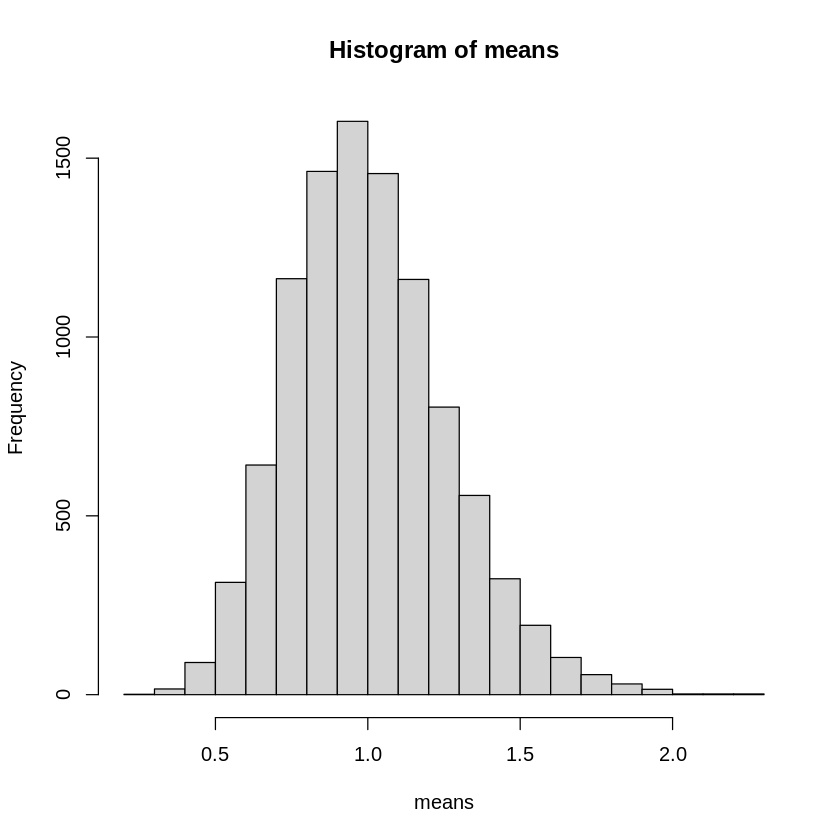

In [31]:
n = 30
rep = 10000
means = (replicate(rep,mean(rnorm(n)^2)))
hist(means)

<details>
<summary>▶️ Click to show the solution</summary>

```r
repetitions = 10^4
N = 30

means <- replicate(repetitions, mean(rnorm(N)^2))
hist(means)
# we can see from the histogram that there is still a right skew in the data
# so we can see that even though n = 30 the sample mean is not very close to being normally distributed. If we were to use the CLT to approximate probabilities, they'd still be quite off in the tails of the distribution

```

</details>

Now try some larger sample sizes yourself. Roughly how many observations per sample do you need before the CLT approximation seems reasonable?

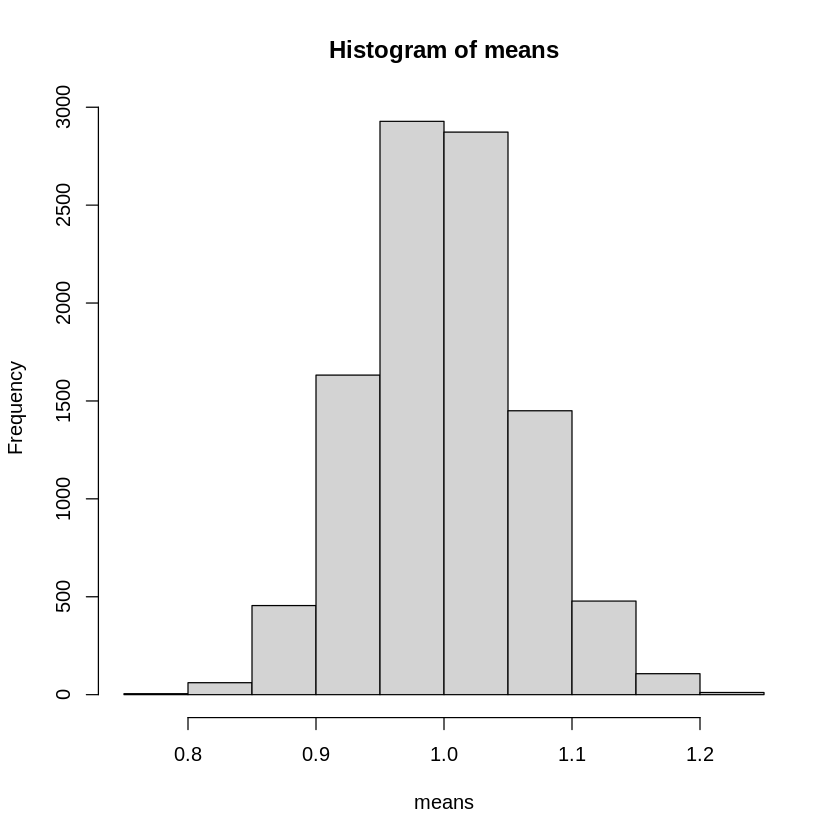

In [40]:
n = 500
means = replicate(rep,mean(rnorm(n)^2))
hist(means)

<details>
<summary>▶️ Click to show the solution</summary>

```r
repetitions = 10^4
N = 500

means <- replicate(repetitions, mean(rnorm(N)^2))

hist(means)

# using this approach, our sample size seems to need to be somewhere around several hundred before we see good convergence to normality
# visually, the histogram looks fairly symmetric around 150-200 samples
```

</details>

### Poisson(2)
Now, let's try with a less skewed distribution. Simulate $10^4$ observations from a $Poisson(2)$ distribution, plot them on a histogram and comment on the shape of the distribution.

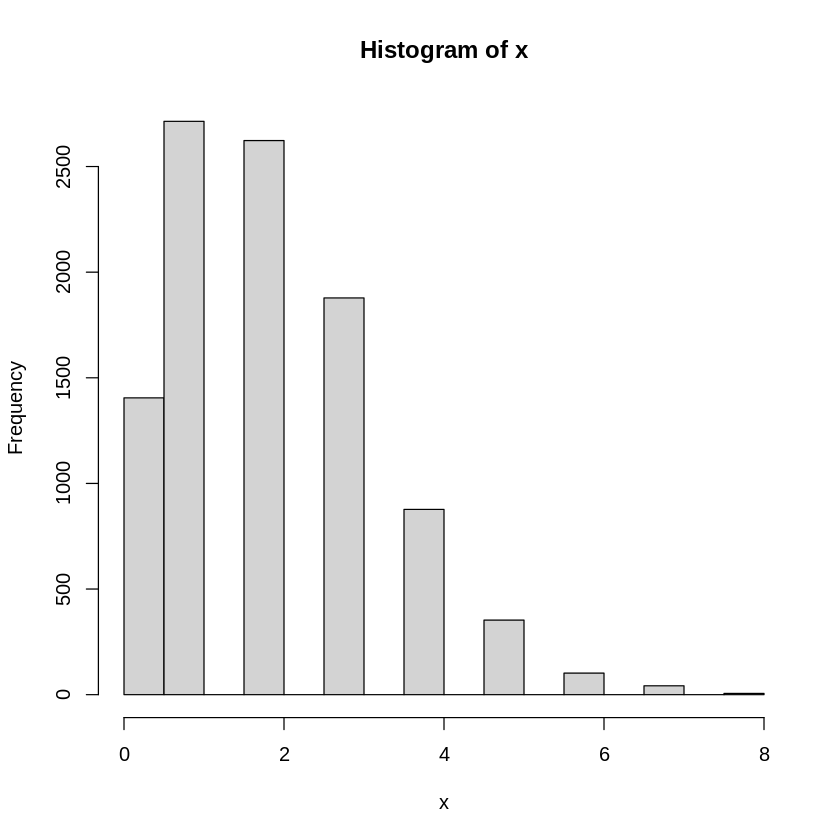

In [42]:
x = rpois(rep,2)
hist(x)

<details>
<summary>▶️ Click to show the solution</summary>

```r
repetitions = 10^4
x = rpois(repetitions, 2)
hist(x, main = "Histogram of a i.i.d. sample from Pois(2)")

# the distribution is positively skewed with the majority of values falling between 0 and 4 followed by a few values in the right tail
```

</details>

Roughly what sample size do we require here for approximate normality of the sample mean to hold?

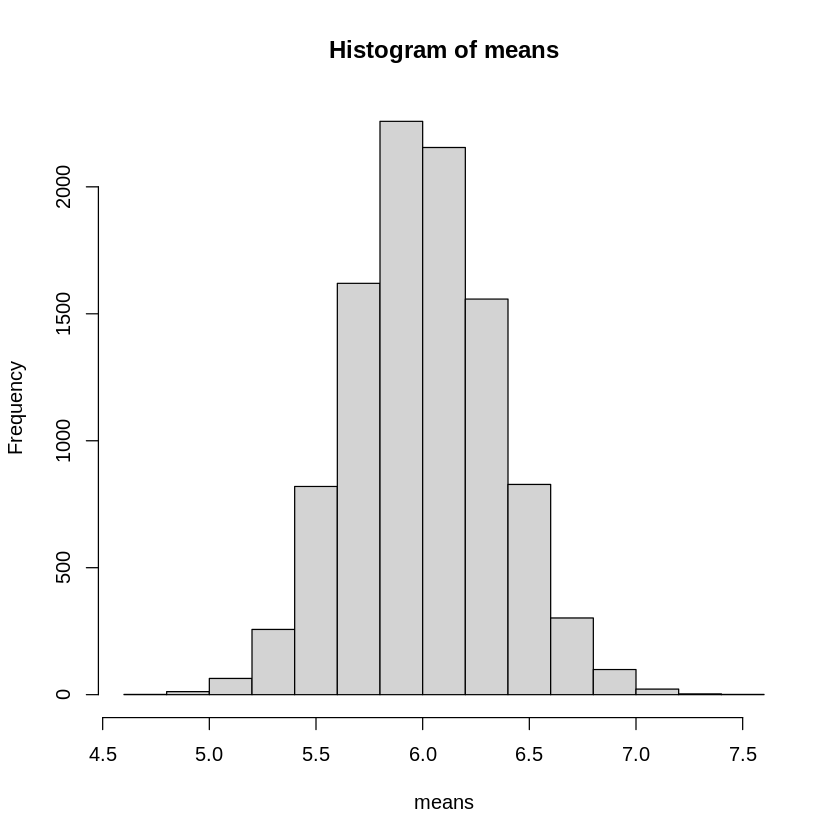

In [45]:
n =500
rep = 10000
means = (replicate(rep,mean(rpois(n,2)^2)))
hist(means)

<details>
<summary>▶️ Click to show the solution</summary>

```r
repetitions = 10^4
N = 30

means <- replicate(repetitions, mean(rpois(N, 2)))

hist(means)

# we can see that the rough rule of thumb N=30 works reasonably here
```

</details>

### Poisson(10)
Now let's simulate from $Poisson(10)$. What's the minimum sample size for which the CLT gives a good approximation of the sample mean?

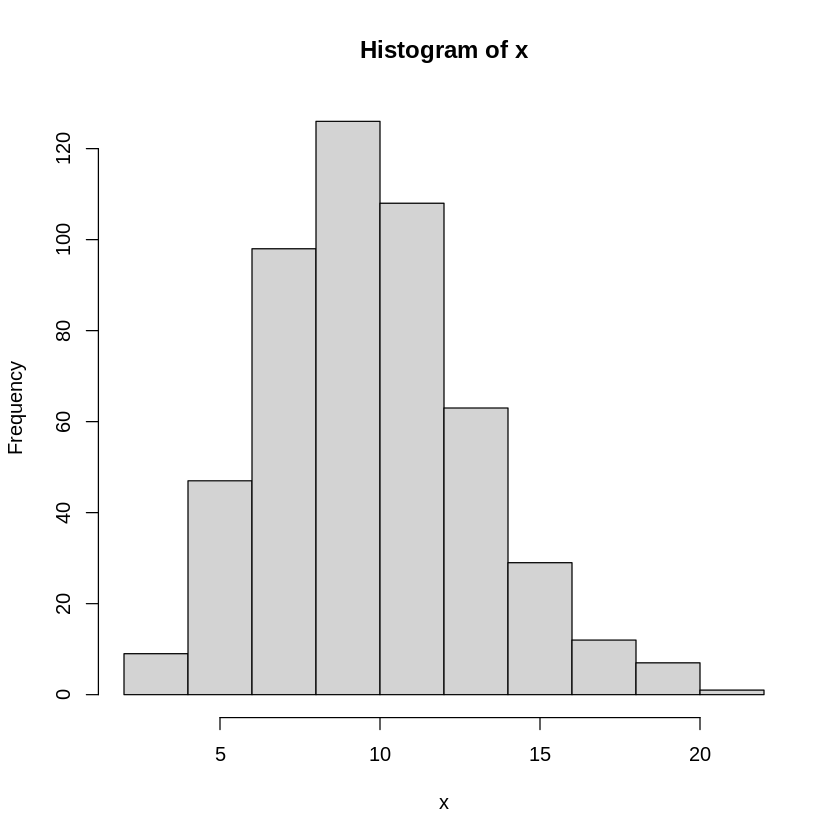

In [51]:
x=rpois(n,10)
hist(x)

<details>
<summary>▶️ Click to show the solution</summary>

```r
repetitions = 10^4

hist(rpois(repetitions, 10))

# we can see that the distribution is fairly symmetric
# there is a slight right skew, but it is quite weak

N = 10

means <- replicate(repetitions, mean(rpois(N, 10)))

hist(means)
# so here even a small sample size is good enough for a decent normal approximation of the sample mean

```

</details>

### N(0,1)
What if the distribution we are sampling from is $N(0,1)$? What sample size do we need for the sampling distribution of the mean to be approximately normal?

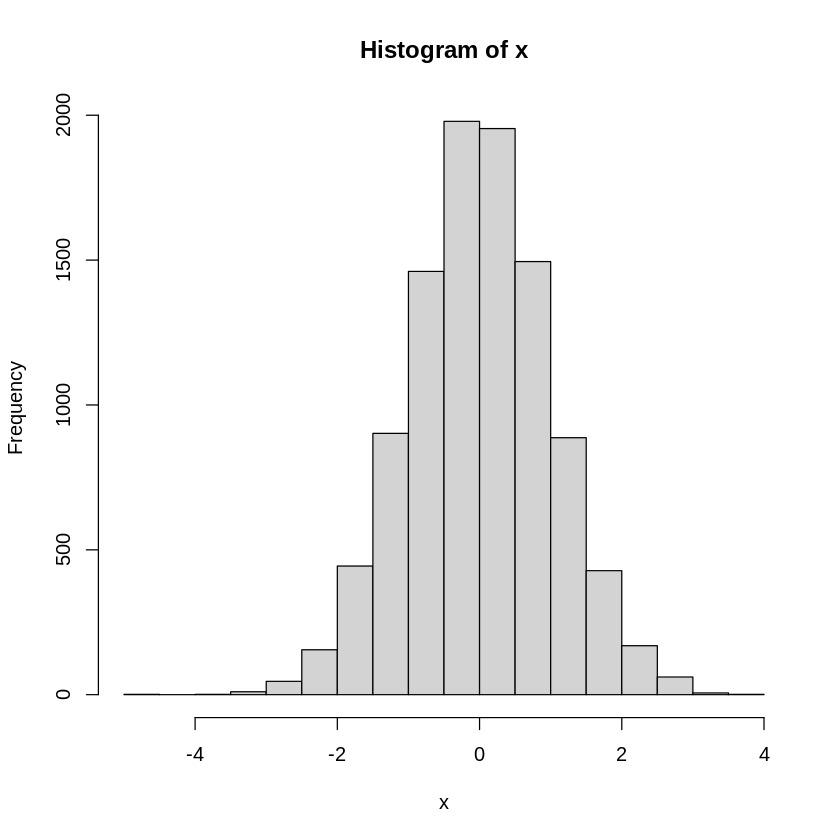

In [52]:
x = rnorm(rep)
hist(x)

<details>
<summary>▶️ Click to show the solution</summary>

```r
# if our samples are from $N(0,1)$, they're already normally distributed
# hence, the mean will also be normally distributed, even for a sample size of 1!

# if you're skeptical and want to verify ....
repetitions <- 10^4

x <- rnorm(repetitions)
hist(x)

# our histograms bery closely resembles the normal distribution

```

</details>

## Question: Estimating the Probability of $a < \bar{x} < b$

A beverage plant calibrates a bottling machine to fill 33 cL bottles, but there is some variability in the process, and from time to time, the machine needs adjustment. Every hour, an employee takes a sample of ten bottles and measures the amount of beverage in each one to monitor the machine. Prior testing shows that the volume of each bottle has a mean of 33 cL and a variance of 0.6 cL. What is the (approximate) probability of observing a sample mean of $\bar{x}\leq 32.7$ cL based on a sample of \(n=10\) bottles?



In [53]:
pnorm(32.7, mean = 33, sd = sqrt(0.6/10))

[1] 0.1103357

<details>
<summary>▶️ Click to show the solution</summary>

We approximate the sampling distribution of the sample mean $\bar{x}$ with  

$$
\displaystyle
\bar{x} \sim \mathcal{N}\big(\mu, \sigma^2/n\big) \sim \mathcal{N}(33, 0.6/10).
$$

So $\Pr(\bar{x} \le 32.7)$ can be found using the standard normal distribution:  

$$
\displaystyle
\begin{aligned}
\Pr(\bar{x} \le 32.7)
&= \Pr\Bigg(\frac{\bar{x}-\mu}{\sigma/\sqrt{n}} \le \frac{32.7-33}{\sqrt{0.6/10}}\Bigg) \\
&= \Pr(Z \le -1.22) \\
&\approx 0.11.
\end{aligned}
$$

This probability can be calculated using the `pnorm()` function in R.

```r
pnorm(32.7, mean = 33, sd = sqrt(0.6/10))
```

</details>

# Asymptotic Sampling Distribution of Sample Proportion

## Question: Coffee vs Tea

Suppose a population has a proportion $p = 0.6$ of people who prefer coffee over tea. We draw an i.i.d. random sample of size $n = 100$ from the population. Let $\hat{p}$ denote the sample proportion.  Compute the approximate probability that the sample proportion of people preferring coffee is between 0.55 and 0.65.



In [55]:
1 - pnorm(-121.35,0,1) - pnorm(-121.15,0,1)

[1] 1

<details>
<summary>▶️ Click to show the solution</summary>

Here we have $np = 100\times 0.6 = 60 > 10$ and $n(1-p) = 100\times 0.4 = 40 > 10$ so a normal approximation will be reasonable:
$$
\begin{align}
\displaystyle \Pr(0.55 \le \hat{p} \le 0.65) &= \Pr\left(\frac{0.55-0.6}{\sqrt{0.6 \cdot 0.4 / 100}} \le Z \le \frac{0.65-0.6}{\sqrt{0.6 \cdot 0.4 / 100}}\right) \\
&\approx \Pr(-1.021 \le Z \le 1.021) \\
&\approx 0.692
\end{align}
$$


We can compute this in **R** using `pnorm()`:

```r
p = 0.6
n = 100
se = sqrt(p*(1-p)/n)

pnorm(0.65, mean = p, sd = se) - pnorm(0.55, mean = p, sd = se)

# or equivalently
pnorm(1.021) - pnorm(-1.021)


```

</details>

# Workshop Questions


## Question 1
If 10% of all passengers travelling on a certain airline alter their flight arrangements:

a) Approximate the probability that, among 150 persons travelling on this airline, at least 7 alter their flight arrangements.

b) Find the exact value in R and compare.

In [57]:
## (150 choose 7) 10^7 * 150^143
## approximation with normal dist
## pr(x >= 7) = 1- pr (x < 6)
## mean = n * p = 15
## sd = np*(1-p) = 15*0.9 = 13.5
pnorm(6,15,sqrt(13.5))

[1] 0.007152939

<details>
<summary>▶️ Click to show the solution</summary>

Solutions will be released at the end of the week!

</details>

## Question 2

An automotive battery producer makes a certain model of battery with an average life of 1110 days with a standard deviation of 80 days. Given a sample of size $n = 40$, find the probability that:

a) The average battery for the sample is between 1100 and 1110 days.

<details>
<summary>▶️ Click to show the solution</summary>

Solutions will be released at the end of the week!

</details>

b) The average battery life for the sample is greater than 1120 days

<details>
<summary>▶️ Click to show the solution</summary>

Solutions will be released at the end of the week!

</details>

## Question 3


A factory produces light bulbs, and historically, 5% of them are defective. To monitor quality, an inspector randomly selects 250 bulbs each day. Let $\hat{p}$ be the sample proportion of defective bulbs in a daily sample.  


a) Use the CLT, approximate the sampling distribution of $\hat{p}$.  


<details>
<summary>▶️ Click to show the solution</summary>

Solutions will be released at the end of the week!

</details>

b) Explain why the CLT approximation is reasonable in this context.

<details>
<summary>▶️ Click to show the solution</summary>

Solutions will be released at the end of the week!

</details>

c) Compute the probability that the daily sample contains more than 10% defective bulbs.  


<details>
<summary>▶️ Click to show the solution</summary>

Solutions will be released at the end of the week!

</details>

## Question 4
A lecture theater holds a maximum on 150 students. However, the university knows that, on average, only 27% of those enrolled into a unit will attend. In response to this, there is a policy allowing 500 students to enroll for the lecture. Calculate the approximate probability that more than 150 students will attend the lecture.

<details>
<summary>▶️ Click to show the solution</summary>

Solutions will be released at the end of the week!

</details>

## Challenge question
Using the knowledge that the sum of independent and identically distributed (iid) geometric random variables forms a negative binomial random variable, use the CLT to build a normal approximation for the negative binomial distribution.

<details>
<summary>▶️ Click to show the solution</summary>

Solutions will be released at the end of the week!

</details>